# SHAP Plots Examples

This notebook demonstrates the usage of the SHAPPlots class methods for model interpretability using SHAP (SHapley Additive exPlanations) values. The SHAPPlots class provides comprehensive visualization tools for understanding feature importance, individual predictions, and model behavior.

SHAP values provide a unified framework for interpreting model predictions by quantifying the contribution of each feature to individual predictions.

In [1]:
import numpy as np
import pandas as pd
import shap
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from kvbiii_plots.evaluation.shap_plots import SHAPPlots

%matplotlib inline

In [2]:
shap_plots = SHAPPlots()

import warnings

warnings.filterwarnings("ignore")

print("SHAPPlots class initialized successfully!")
print("Available plot methods:")
methods = [method for method in dir(shap_plots) if method.startswith("plot_")]
for method in methods:
    print(f"  - {method}")

SHAPPlots class initialized successfully!
Available plot methods:
  - plot_custom_shap_beeswarm
  - plot_shap_bar
  - plot_shap_categorical_box
  - plot_shap_force
  - plot_shap_numerical_scatter


## Generate Sample Data and Train Models

We'll create different datasets and train multiple models to demonstrate various SHAP plotting scenarios including:
- Binary classification
- Multi-class classification
- Different feature types (numerical, categorical)

In [3]:
np.random.seed(42)

X_binary, y_binary = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    n_informative=7,
    n_redundant=2,
    n_clusters_per_class=1,
    random_state=42,
)

feature_names_binary = [f"numerical_feature_{i}" for i in range(X_binary.shape[1])]
X_binary_df = pd.DataFrame(X_binary, columns=feature_names_binary)
y_binary_df = pd.DataFrame(y_binary, columns=["target"])

X_regression, y_regression = make_regression(
    n_samples=1000, n_features=10, n_informative=5, noise=0.1, random_state=42
)

In [4]:
np.random.seed(42)

X_binary_extended = X_binary_df.copy()
X_binary_extended["categorical_A"] = np.random.choice(
    ["Low", "Medium", "High"], size=len(X_binary_df), p=[0.3, 0.4, 0.3]
)
X_binary_extended["categorical_A"] = X_binary_extended["categorical_A"].astype("category")
X_binary_extended["categorical_B"] = np.random.choice(
    ["Type_1", "Type_2", "Type_3", "Type_4"], size=len(X_binary_df), p=[0.25, 0.25, 0.25, 0.25]
)
X_binary_extended["categorical_B"] = X_binary_extended["categorical_B"].astype("category")

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary_extended, y_binary_df, test_size=0.3, random_state=42
)

X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(
    X_regression, y_regression, test_size=0.3, random_state=42
)

print("Train/Test splits completed successfully!")

Train/Test splits completed successfully!


In [5]:
models = {}

lgb_model = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(
    X_binary_train, y_binary_train, categorical_feature=["categorical_A", "categorical_B"]
)
models["lgb_binary"] = lgb_model

lgb_model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(
    X_regression_train,
    y_regression_train,
)
models["lgb_regression"] = lgb_model

print("LightGBM models trained successfully!")

LightGBM models trained successfully!


In [6]:
explainers = {}
shap_values = {}

explainers["lgb_binary"] = shap.TreeExplainer(models["lgb_binary"])
shap_values["lgb_binary"] = explainers["lgb_binary"](X_binary_test[:100])                       

explainers["lgb_regression"] = shap.TreeExplainer(models["lgb_regression"])
shap_values["lgb_regression"] = explainers["lgb_regression"](X_regression_test[:100])

print("SHAP values computed successfully!")
for name, values in shap_values.items():
    print(f"  - {name}: shape {values.values.shape}")

SHAP values computed successfully!
  - lgb_binary: shape (100, 12)
  - lgb_regression: shape (100, 10)


## 1. plot_shap_bar() - Feature Importance Bar Plot

The SHAP bar plot shows the mean absolute SHAP values for each feature, providing a clear ranking of feature importance across all predictions.

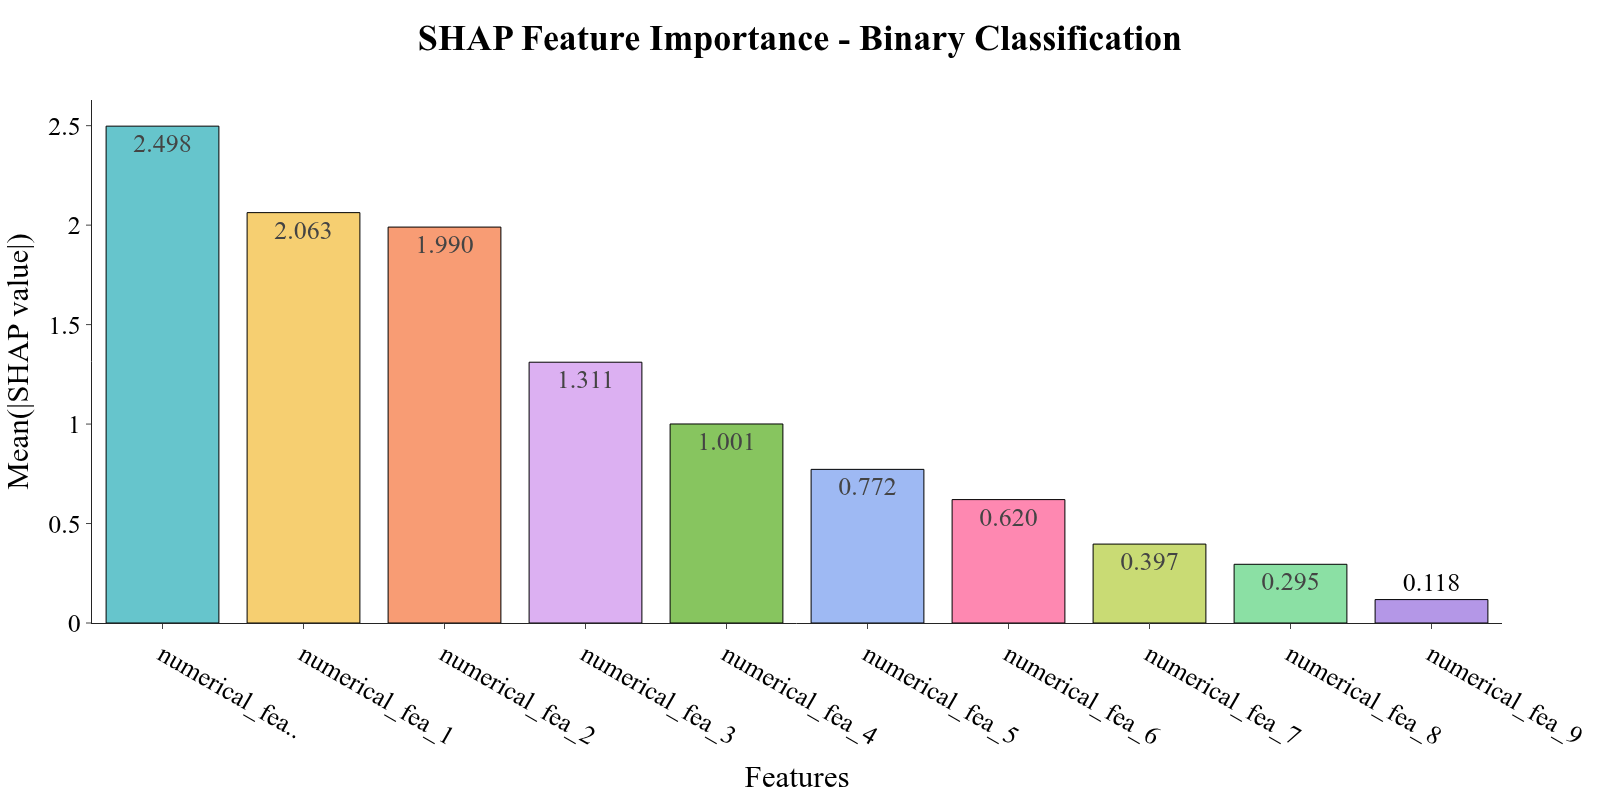

In [7]:
shap_plots.plot_shap_bar(
    shap_values=shap_values["lgb_binary"],
    top_n=10,
    plot_title="SHAP Feature Importance - Binary Classification",
)

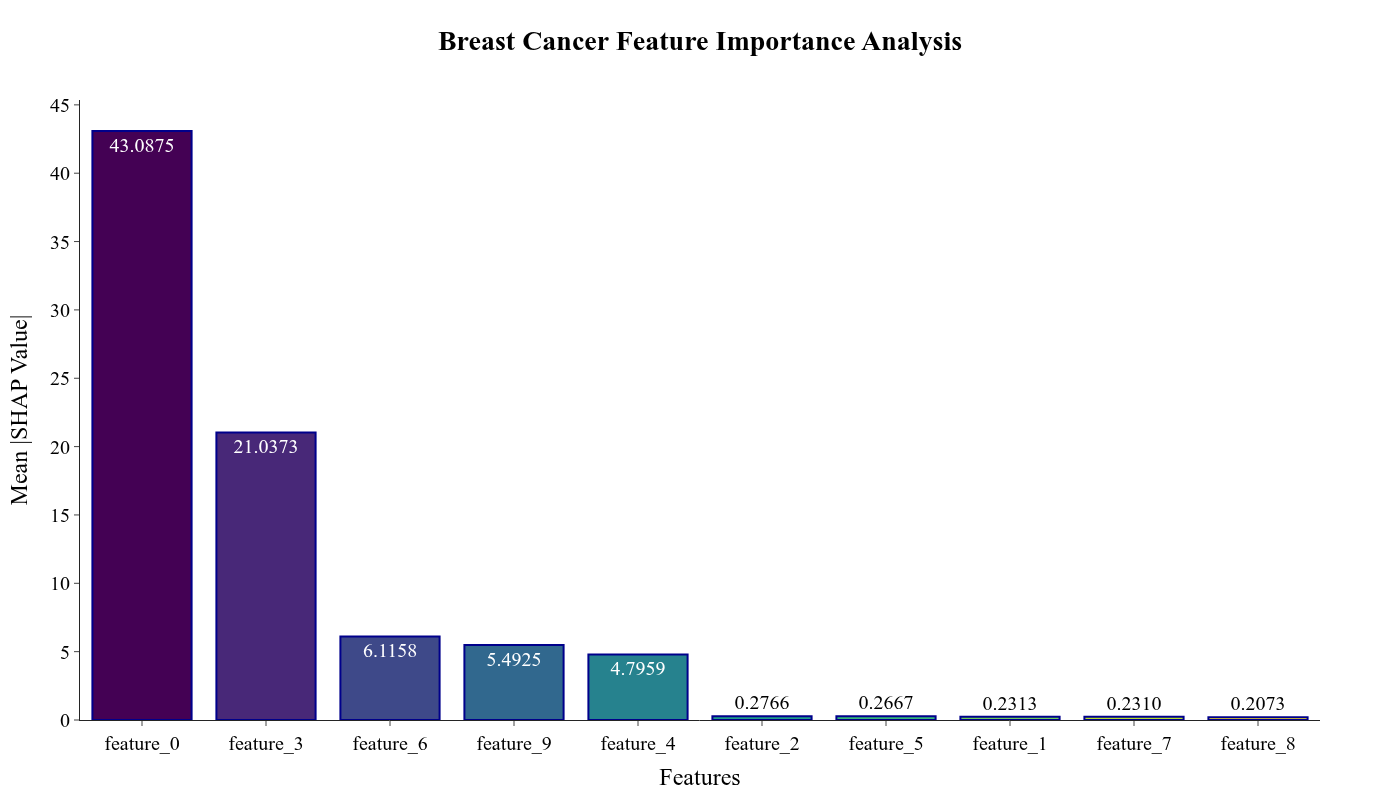

In [8]:
shap_plots.plot_shap_bar(
    shap_values=shap_values["lgb_regression"],
    top_n=15,
    plot_title="Breast Cancer Feature Importance Analysis",
    width=1400,
    height=800,
    xaxis_title="Features",
    yaxis_title="Mean |SHAP Value|",
    color_scale="viridis",
    use_qualitative_colors=False,
    show_values=True,
    value_precision=4,
    font_size=20,
    bar_line_color="darkblue",
    bar_line_width=2,
)

## 2. plot_custom_shap_beeswarm() - Enhanced Beeswarm Plot

The beeswarm plot shows the distribution of SHAP values for top features, with each point representing a single prediction. Color indicates feature value magnitude.

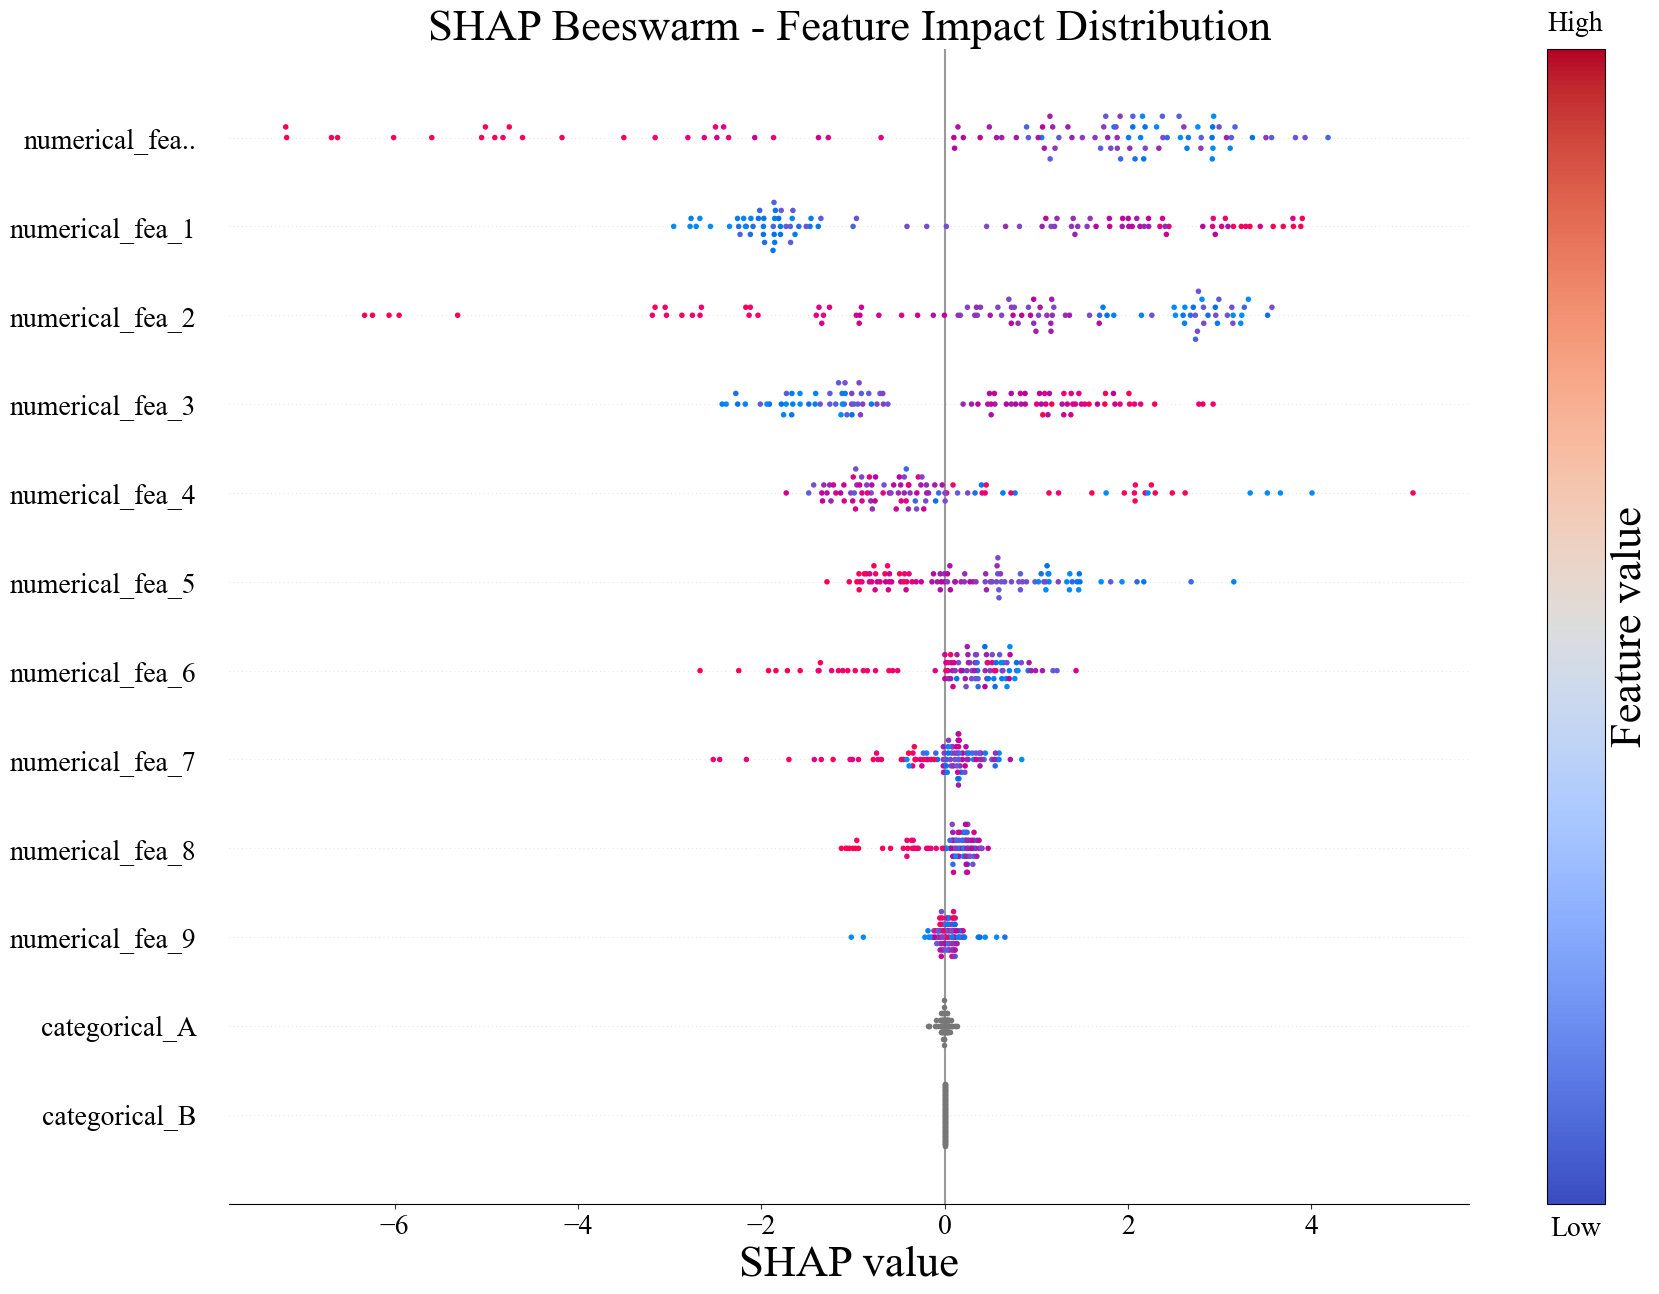

In [9]:
shap_plots.plot_custom_shap_beeswarm(
    shap_values=shap_values["lgb_binary"],
    top_n=20,
    plot_title="SHAP Beeswarm - Feature Impact Distribution",
)

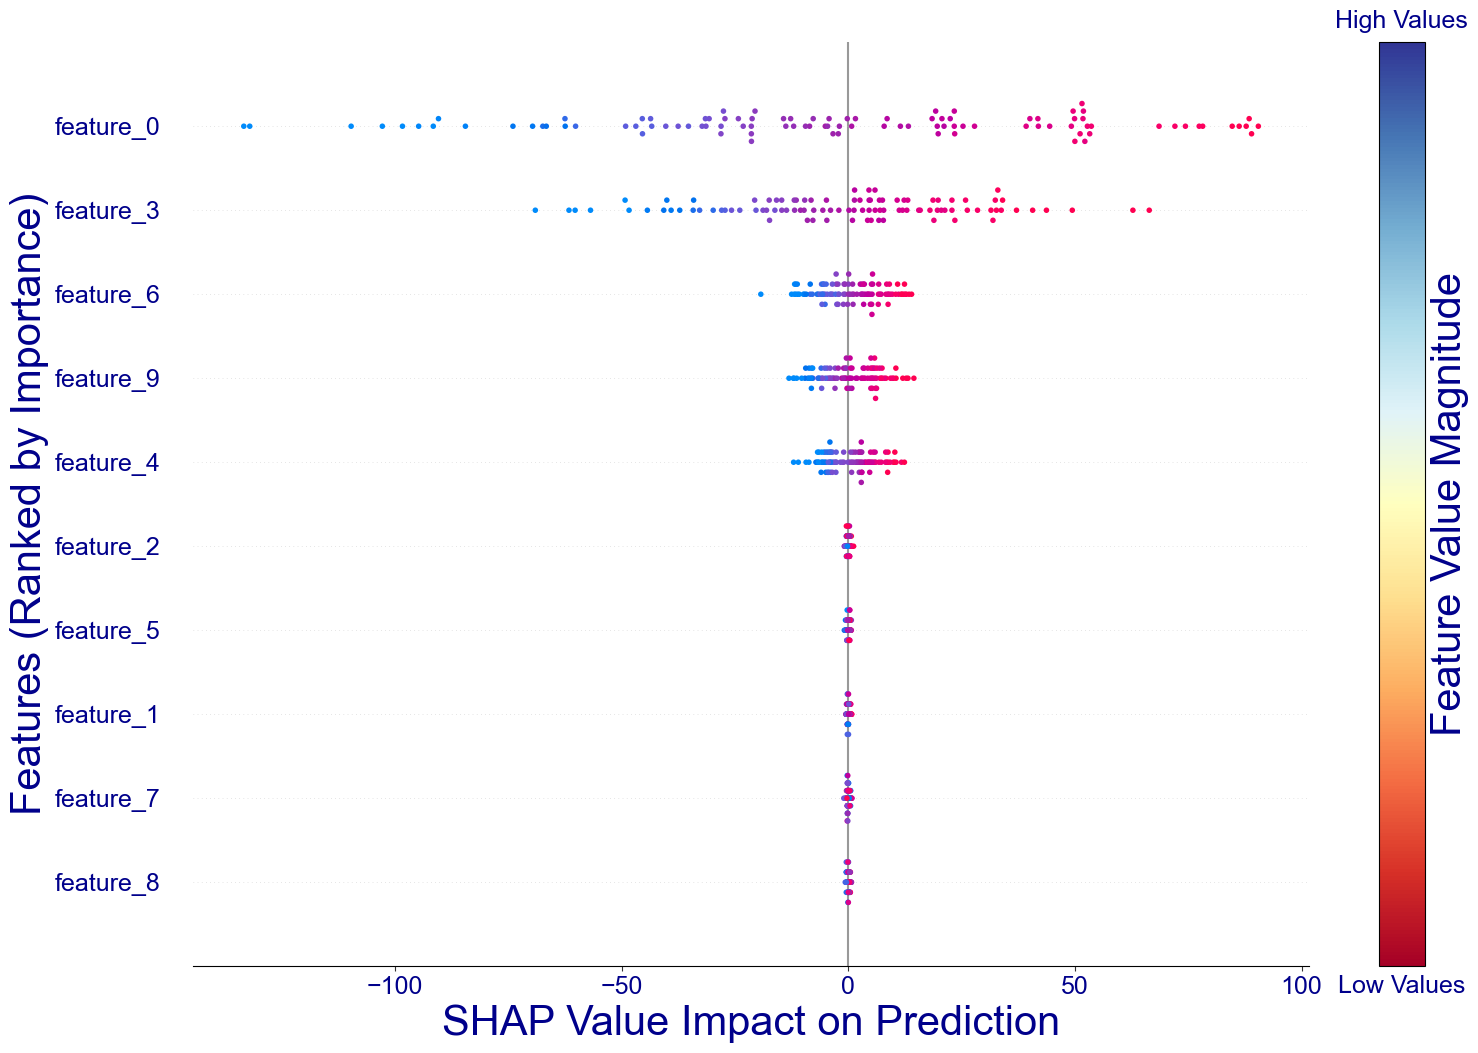

In [10]:
shap_plots.plot_custom_shap_beeswarm(
    shap_values=shap_values["lgb_regression"],
    top_n=12,
    plot_size=(18, 12),
    xlabel="SHAP Value Impact on Prediction",
    ylabel="Features (Ranked by Importance)",
    colormap="RdYlBu",
    colorbar_label="Feature Value Magnitude",
    high_label="High Values",
    low_label="Low Values",
    font_size=18,
    font_name="Arial",
    font_color="darkblue",
    show_colorbar=True,
)

## 3. plot_shap_categorical_box() - Categorical Feature Analysis

Box plots show SHAP value distributions for different categories of a categorical feature, helping understand how different categories impact predictions.

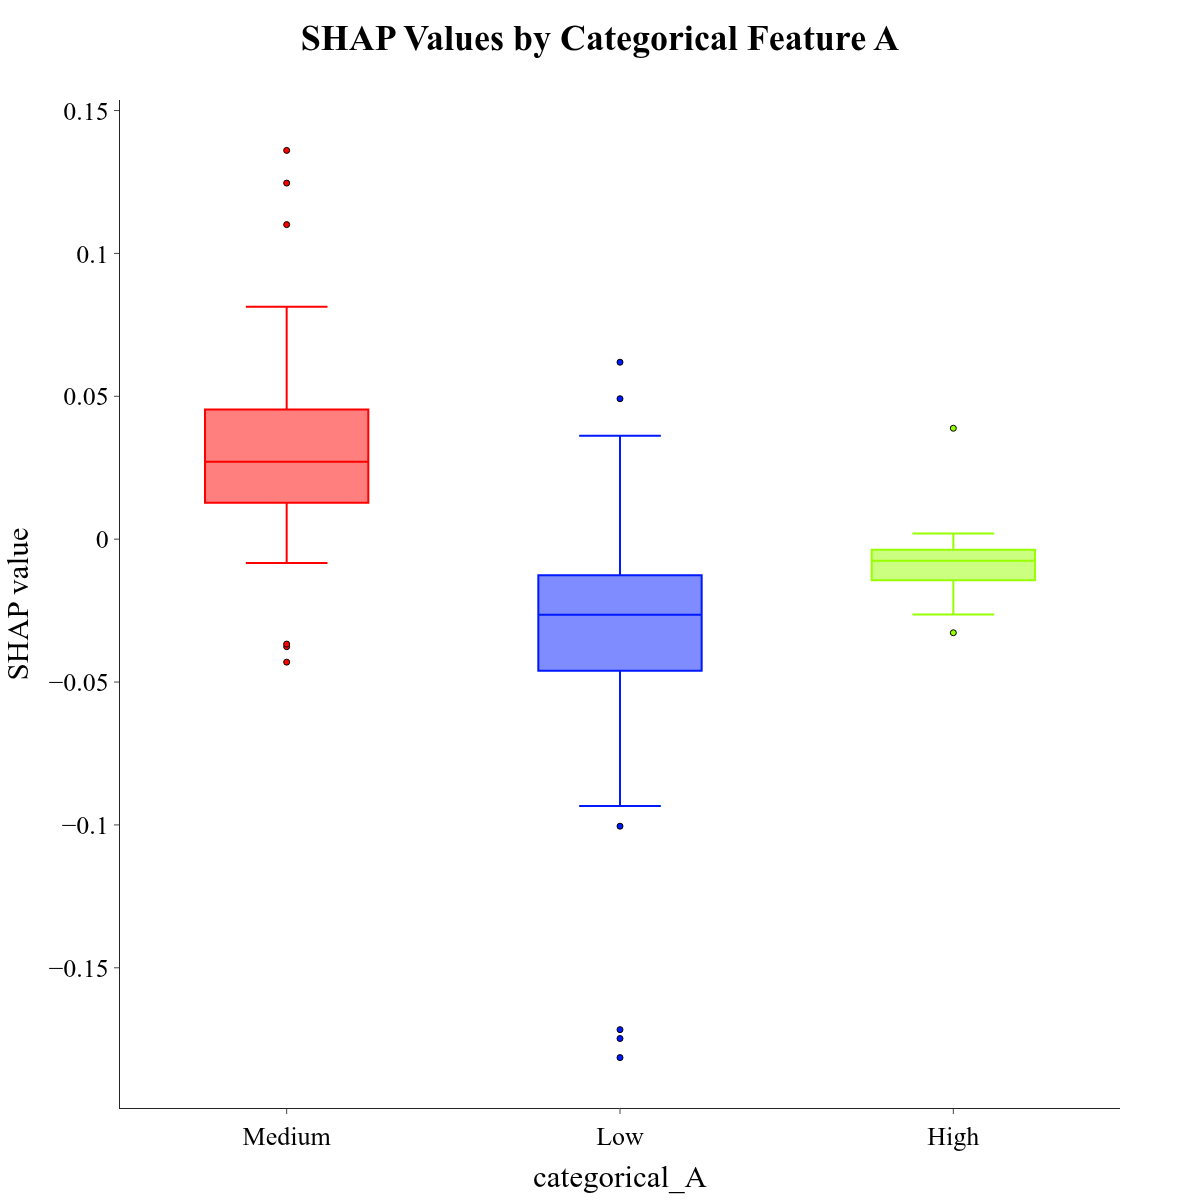

In [11]:
categorical_feature_idx = X_binary_test.columns.get_loc("categorical_A")
categorical_shap = shap_values["lgb_binary"][:, categorical_feature_idx]

shap_plots.plot_shap_categorical_box(
    scatter=categorical_shap,
    feature="categorical_A",
    plot_title="SHAP Values by Categorical Feature A",
)

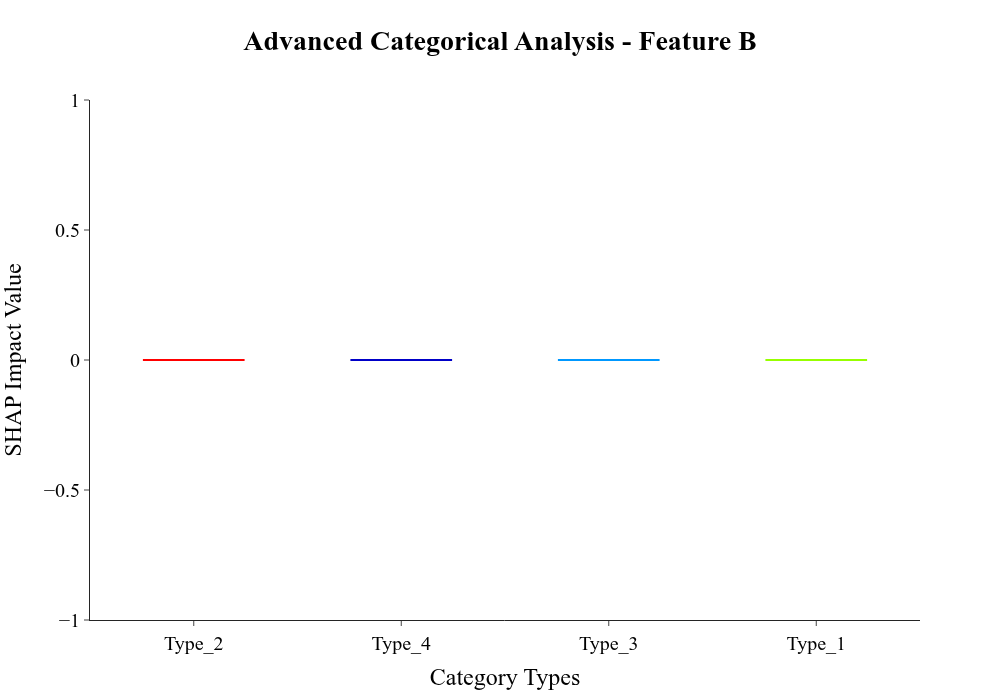

In [12]:
categorical_feature_idx_b = X_binary_test.columns.get_loc("categorical_B")
categorical_shap_b = shap_values["lgb_binary"][:, categorical_feature_idx_b]

shap_plots.plot_shap_categorical_box(
    scatter=categorical_shap_b,
    feature="categorical_B",
    plot_title="Advanced Categorical Analysis - Feature B",
    width=1000,
    height=700,
    xaxis_title="Category Types",
    yaxis_title="SHAP Impact Value",
    font_size=20,
    sort_categories=True,
    sort_by="shap_median",
    show_legend=False,
    box_line_color="darkred",
    box_line_width=2,
    exclude_empty=True,
)

## 4. plot_shap_numerical_scatter() - Numerical Feature Analysis

Scatter plots show the relationship between feature values and their SHAP values, revealing how feature value changes impact model predictions.

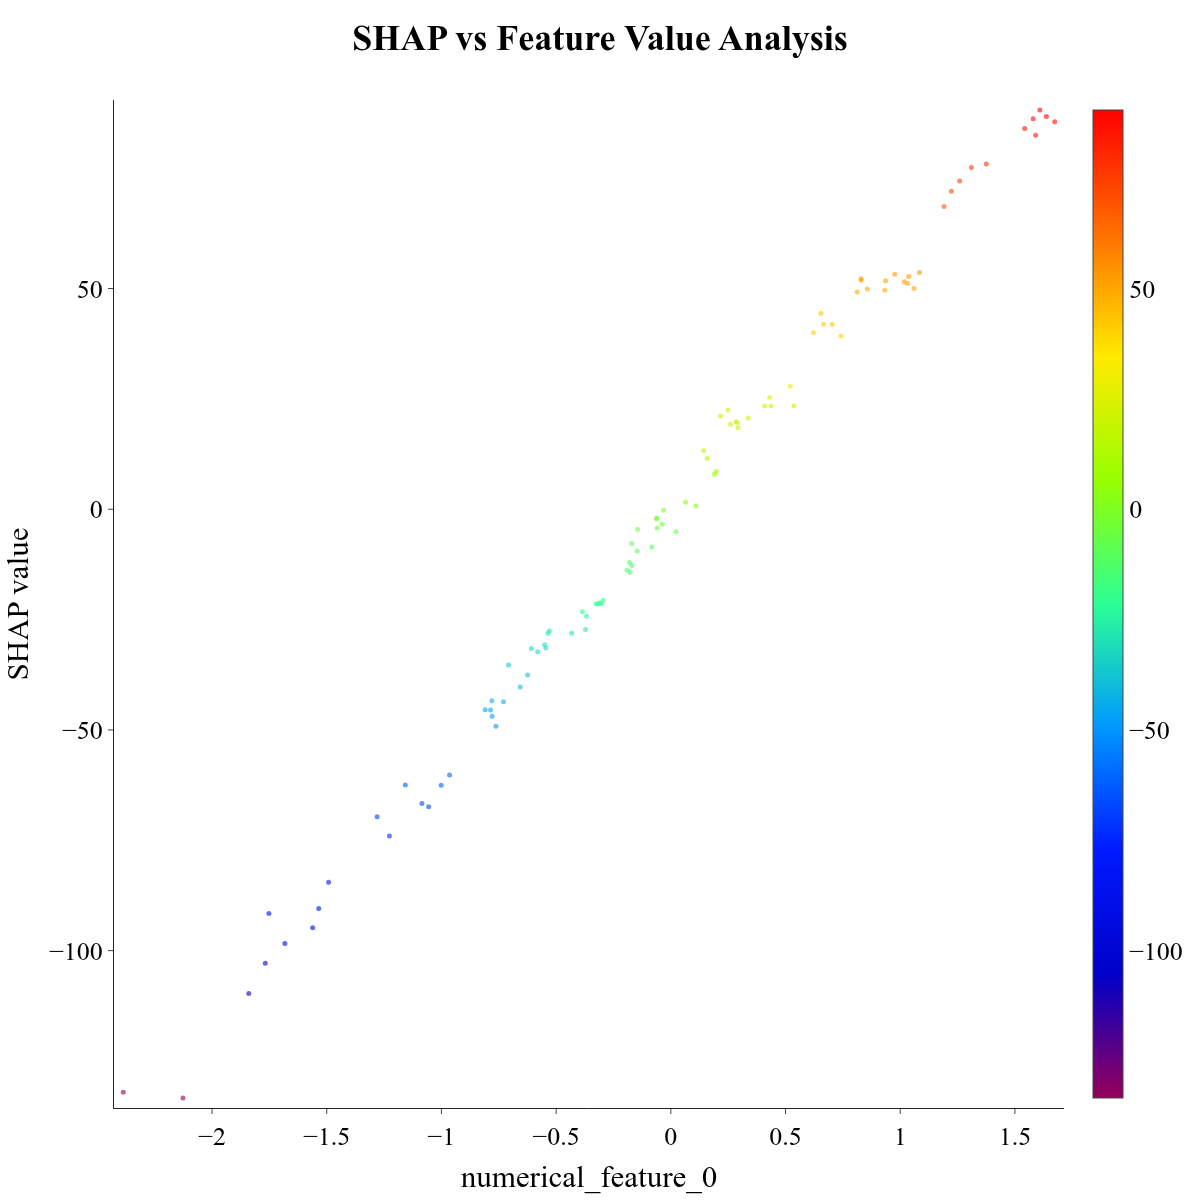

In [13]:
numerical_shap_cancer = shap_values["lgb_regression"][:, 0]

shap_plots.plot_shap_numerical_scatter(
    feature_shap_values=numerical_shap_cancer,
    feature="numerical_feature_0",
    plot_title="SHAP vs Feature Value Analysis",
)

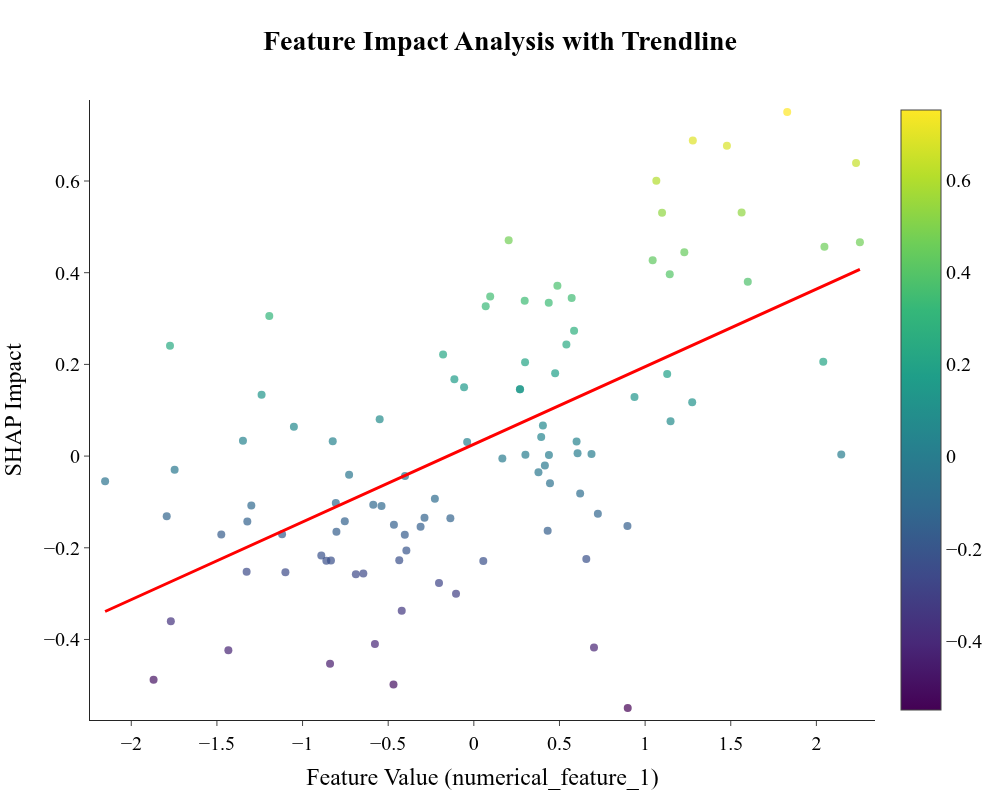

In [14]:
numerical_shap_cancer_2 = shap_values["lgb_regression"][:, 1]

shap_plots.plot_shap_numerical_scatter(
    feature_shap_values=numerical_shap_cancer_2,
    feature="numerical_feature_1",
    plot_title="Feature Impact Analysis with Trendline",
    width=1000,
    height=800,
    xaxis_title="Feature Value (numerical_feature_1)",
    yaxis_title="SHAP Impact",
    colorscale="Viridis",
    marker_size=8,
    marker_opacity=0.7,
    show_colorbar=True,
    colorbar_thickness=40,
    font_size=20,
    axis_margin_percent=2.0,
    add_trendline=True,
    trendline_color="red",
    trendline_width=3,
)

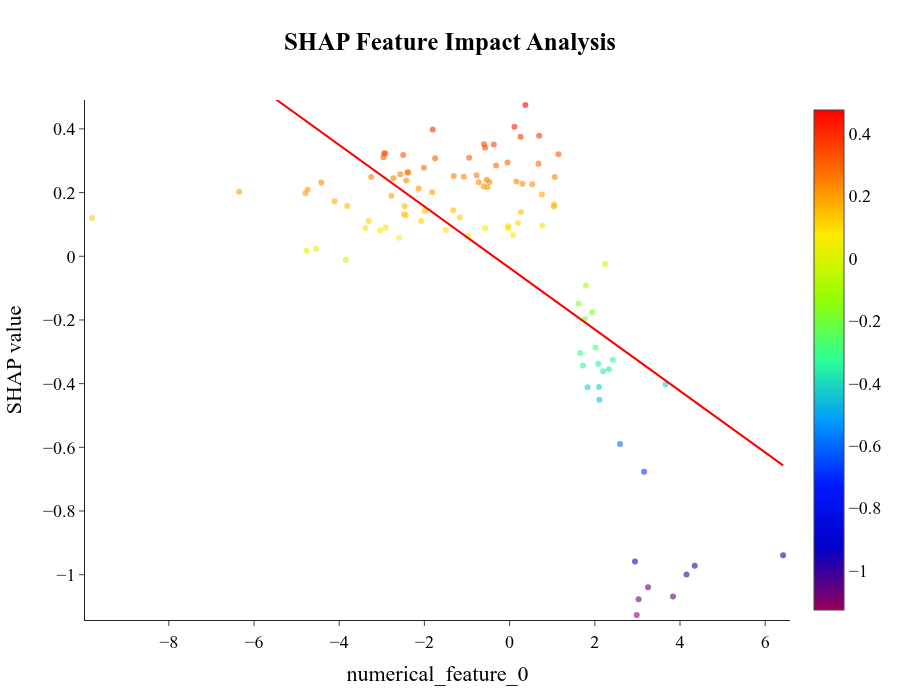

In [15]:
if shap_values["lgb_binary"].values.ndim == 3:
    shap_feature = shap_values["lgb_binary"][:, 0, 0]
else:
    shap_feature = shap_values["lgb_binary"][:, 0]

shap_plots.plot_shap_numerical_scatter(
    feature_shap_values=shap_feature,
    feature="numerical_feature_0",
    plot_title="SHAP Feature Impact Analysis",
    width=900,
    height=700,
    colorscale="Rainbow",
    marker_size=6,
    add_trendline=True,
    font_size=18,
)

## 5. plot_shap_force() - Individual Prediction Explanation

Force plots show how each feature contributes to pushing the model output from the base value to the final prediction for individual samples.

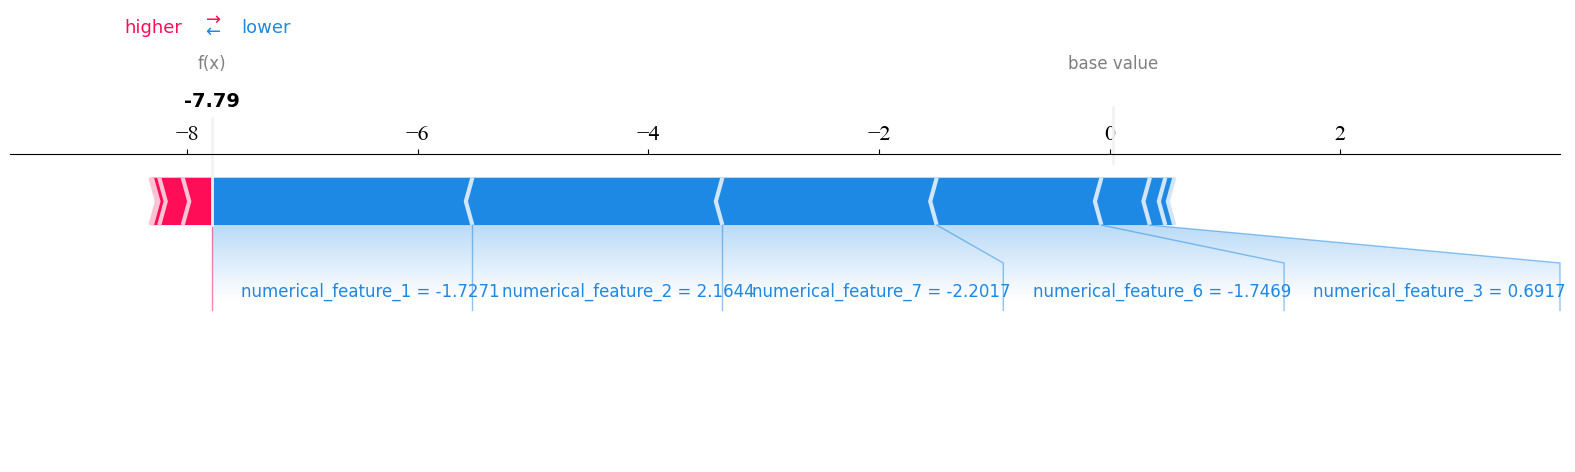

In [16]:
single_prediction_binary = shap_values["lgb_binary"][0]

shap_plots.plot_shap_force(
    observation_shap_values=single_prediction_binary,
    contribution_threshold=0.05,
    figsize=(20, 4),
    font_size=16,
)

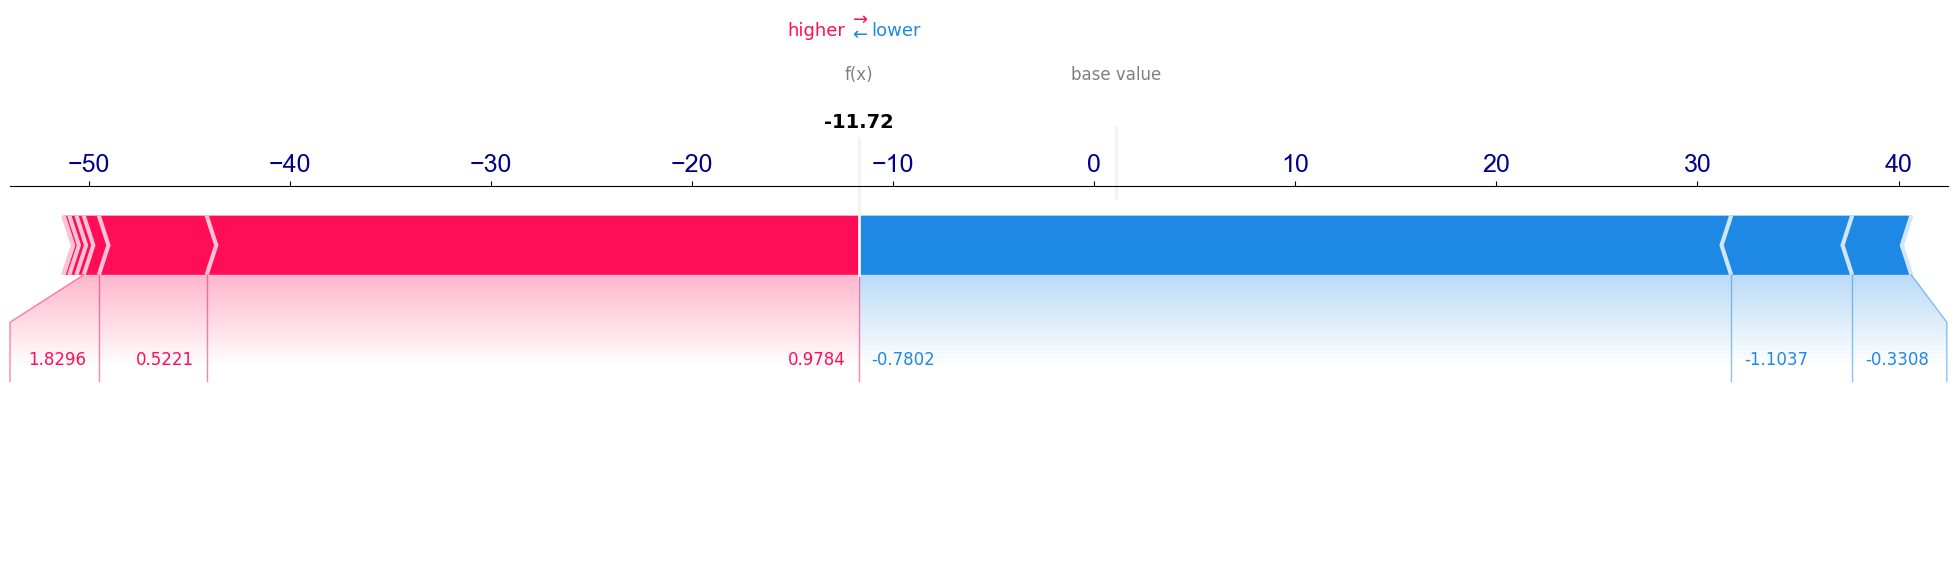

In [17]:
single_prediction = shap_values["lgb_regression"][5]

shap_plots.plot_shap_force(
    observation_shap_values=single_prediction,
    contribution_threshold=0.03,
    figsize=(25, 5),
    font_size=18,
    font_name="Arial",
    font_color="darkblue",
    link="identity",
    text_rotation=0,
)